# Eleven Hybrid Architectures + Ensembles — Deployment-Honest, P100 Build
### Quantum / federated mobile-money fraud detection, evaluated at the true fraud rate

This is the doctoral-grade revision of the eleven-hybrid study. It keeps the eleven distinct architectures and the ensemble stage, but rebuilds the parts that earlier runs showed to be misleading. Five things change.

**1. Evaluation at the real fraud rate (not 50/50).** Earlier metrics were measured on a balanced test set, so average precision sat on a 0.5 floor and did not reflect a 10.2%- or 0.13%-fraud stream. Here every model is scored on a large held-out **balanced** set for a stable ROC, and precision, PR-AUC, precision-at-recall and the alert rate are then **projected analytically to the true prevalence** of each dataset. ROC-AUC is prevalence-independent and reported directly; the projected numbers are the deployment estimate.

**2. A real federated budget.** The federated VQC previously sat at chance because three rounds of one local epoch is not enough. Rounds and local epochs are raised so the federated learners actually converge.

**3. A regularised, cross-validated meta-learner.** The previous stacking meta-learner overfit a tiny validation split. It is replaced by a cross-validated logistic regression on a larger validation set, reported beside the weighted vote and the top-K vote, with an honest comparison against the strongest single model.

**4. Non-IID clients with a meaningful FedProx term.** Under an IID split with equal clients, FedAvg and FedProx collapse to near-duplicates. The clients are now a Dirichlet label-skew partition and the FedProx coefficient is raised, so the aggregation choice genuinely matters — which is also the realistic setting for separate institutions.

**5. P100 usage.** The classical federated network runs on the GPU. The quantum circuits run on `lightning.qubit` (CPU), which is the fastest backend for four-to-eight-qubit circuits; `lightning.gpu`/cuStateVec needs compute capability 7.0+ and the P100 is 6.0. A flag lets you move the circuits onto the GPU via `default.qubit` if you prefer a single-device run.

## 1. Setup

In [1]:
!pip install -q --upgrade-strategy only-if-needed pennylane pennylane-lightning gdown
import warnings; warnings.filterwarnings("ignore")
print("Install complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 780.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.8 MB/s eta 0:00:00
Install complete.


In [2]:
import os, time, random, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing   import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition   import PCA
from sklearn.svm             import SVC
from sklearn.linear_model    import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics         import roc_auc_score, average_precision_score, f1_score, roc_curve, brier_score_loss
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml

SEED = 42
def set_seed(s):
    np.random.seed(s); torch.manual_seed(s); random.seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
set_seed(SEED)
print(f"PennyLane {qml.__version__} | PyTorch {torch.__version__}")

PennyLane 0.45.1 | PyTorch 2.10.0+cpu


The next cell runs a real CUDA kernel launch (the operation that crashes on a broken GPU build) and falls back to CPU on failure. By default the **classical** federated network uses the GPU while the **quantum** circuits use `lightning.qubit` on CPU. Set `QUANTUM_ON_GPU = True` to push the circuits onto the GPU through `default.qubit` instead.

In [3]:
import subprocess
QUANTUM_ON_GPU = False     # True -> run circuits on GPU via default.qubit (single device, often slower for <=8 qubits)

try:
    smi = subprocess.run(["nvidia-smi","--query-gpu=name,memory.total","--format=csv,noheader"],
                         capture_output=True, text=True, timeout=5)
    print("GPU         :", smi.stdout.strip() or "(none)")
except Exception as e:
    print("nvidia-smi  :", e)
gpu_ok = False
if torch.cuda.is_available():
    try:
        x = torch.randn(64,64,device="cuda"); _ = (x @ x.T).sum().item()
        bn = torch.nn.BatchNorm1d(8).to("cuda"); _ = bn(torch.randn(8,8,device="cuda")).sum().item()
        gpu_ok = True; print("Kernel launch OK - CUDA functional.")
    except Exception as e:
        print("Kernel launch FAILED:", str(e)[:120])

cdevice = torch.device("cuda") if gpu_ok else torch.device("cpu")          # classical federated net
device  = torch.device("cuda") if (gpu_ok and QUANTUM_ON_GPU) else torch.device("cpu")   # quantum torch models
QML_DEV  = "default.qubit" if device.type=="cuda" else "lightning.qubit"
QML_DIFF = "backprop"      if device.type=="cuda" else "adjoint"
print(f"\nclassical net device : {cdevice}")
print(f"quantum  model device: {device}  | simulator: {QML_DEV} ({QML_DIFF})")
if device.type=="cpu" and gpu_ok:
    print("(circuits on CPU lightning.qubit - fastest for <=8 qubits; P100 cc 6.0 < 7.0 so no cuStateVec)")

nvidia-smi  : [Errno 2] No such file or directory: 'nvidia-smi'

classical net device : cpu
quantum  model device: cpu  | simulator: lightning.qubit (adjoint)


In [4]:
# Recovery cell - run ONLY if CUDA failed above and you want GPU speed, then restart.
# !pip uninstall -y torch torchvision torchaudio
# !pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121
# import os; os.kill(os.getpid(), 9)


## 2. Data — two benchmarks, unified schema

In [5]:
import gdown, glob, shutil
IS_KAGGLE = os.path.exists('/kaggle')
DATA_DIR  = '/kaggle/working/data' if IS_KAGGLE else '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)
PRIMARY_PATH, COMPARISON_PATH = f'{DATA_DIR}/primary.csv', f'{DATA_DIR}/comparison.csv'

# ===================== SESSION SELECTOR (Kaggle has a 12h/session cap) =====================
# Set this to ONE dataset per session, then run all seeds for it. Session 1 does Azamuke,
# session 2 does PaySim. Leave both for a single combined run when time allows.
RUN_DATASETS = ['PaySim (Lopez-Rojas)']
#   session 1 ->  RUN_DATASETS = ['Primary (Azamuke 2024)']
#   session 2 ->  RUN_DATASETS = ['PaySim (Lopez-Rojas)']
# ==========================================================================================

def _find(pats):
    for p in pats:
        m = glob.glob(p, recursive=True)
        if m: return m[0]
    return None
if 'PaySim (Lopez-Rojas)' in RUN_DATASETS:
    pay = _find(['/kaggle/input/**/PS_*.csv','/kaggle/input/*paysim*/*.csv','/kaggle/input/*PaySim*/*.csv']) if IS_KAGGLE else None
    if pay and not os.path.exists(COMPARISON_PATH): shutil.copy(pay, COMPARISON_PATH)
    elif not os.path.exists(COMPARISON_PATH): gdown.download(id='1RyHztdRMYei4N3PBHLGnwgL0Lrfrfmx9', output=COMPARISON_PATH, quiet=False, fuzzy=True)
    print('Comparison', round(os.path.getsize(COMPARISON_PATH)/1e6,1),'MB')
if 'Primary (Azamuke 2024)' in RUN_DATASETS:
    aza = _find(['/kaggle/input/*azamuke*/*.csv','/kaggle/input/*mobile*money*/*.csv','/kaggle/input/*synthetic*mobile*/*.csv']) if IS_KAGGLE else None
    if aza and not os.path.exists(PRIMARY_PATH): shutil.copy(aza, PRIMARY_PATH)
    elif not os.path.exists(PRIMARY_PATH): gdown.download(id='12p6v5_1fFCKUJgO2gnrKMr013pUNQmtf', output=PRIMARY_PATH, quiet=False, fuzzy=True)
    print('Primary   ', round(os.path.getsize(PRIMARY_PATH)/1e6,1),'MB')

Downloading...
From (original): https://drive.google.com/uc?id=1RyHztdRMYei4N3PBHLGnwgL0Lrfrfmx9
From (redirected): https://drive.google.com/uc?id=1RyHztdRMYei4N3PBHLGnwgL0Lrfrfmx9&confirm=t&uuid=fe97da03-031f-4959-8fea-d9c9307c5f0f
To: /kaggle/working/data/comparison.csv
100%|██████████| 494M/494M [00:05<00:00, 82.6MB/s]

Comparison 493.5 MB


In [6]:
STD_COLS = ['txType','amount','oldBalSender','newBalSender','oldBalRecipient','newBalRecipient','step','isFraud']
AZ_REN = {'transactionType':'txType','oldBalInitiator':'oldBalSender','newBalInitiator':'newBalSender'}
PS_REN = {'type':'txType','oldbalanceOrg':'oldBalSender','newbalanceOrig':'newBalSender',
          'oldbalanceDest':'oldBalRecipient','newbalanceDest':'newBalRecipient'}
def load_dataset(path, name):
    df = pd.read_csv(path); cols = set(df.columns)
    if 'transactionType' in cols: schema='Azamuke 2024'; df=df.rename(columns=AZ_REN)
    elif 'type' in cols and 'oldbalanceOrg' in cols:
        schema='PaySim (Lopez-Rojas)'; df=df.rename(columns=PS_REN)
        df=df.drop(columns=[c for c in ('nameOrig','nameDest','isFlaggedFraud') if c in df.columns])
    else: raise ValueError(f"unknown schema: {sorted(cols)}")
    df=df[STD_COLS].copy()
    print(f'{name:25s} | {schema:22s} | {len(df):>10,} rows | fraud {df["isFraud"].mean()*100:5.2f}%')
    return df
_LOADERS = {'Primary (Azamuke 2024)': (PRIMARY_PATH,'PRIMARY'),
            'PaySim (Lopez-Rojas)'  : (COMPARISON_PATH,'COMPARISON')}
DATASETS = {n: load_dataset(p,tag) for n,(p,tag) in _LOADERS.items() if n in RUN_DATASETS}
# true operating prevalence of each stream (used to project deployment metrics)
PREVALENCE = {n: float(d['isFraud'].mean()) for n,d in DATASETS.items()}
print('true prevalence:', {k: round(v,4) for k,v in PREVALENCE.items()})

COMPARISON                | PaySim (Lopez-Rojas)   |  6,362,620 rows | fraud  0.13%
true prevalence: {'PaySim (Lopez-Rojas)': 0.0013}


## 3. Features and leakage-safe preprocessing

Sixteen features, as in the base project. Row-wise features are computed up front; the 95th-percentile `largeTransaction` threshold, the scaler, PCA, and angle normaliser are all fit on the **training split only** and applied unchanged to validation and to the held-out evaluation set.

In [7]:
TARGET = 'isFraud'
ROWWISE = ['txType_enc','logAmount','oldBalSender','newBalSender','oldBalRecipient','newBalRecipient',
           'balDiffSender','balDiffRecipient','amtToOldBalRatio','zeroOldBalSender','zeroNewBalSender',
           'senderDrained','hourOfDay','dayOfWeek','step']
FEATURE_ORDER = ROWWISE + ['largeTransaction']
def engineer_features(df_in):
    df = df_in.copy()
    df['txType_enc']       = LabelEncoder().fit_transform(df['txType'])
    df['logAmount']        = np.log1p(df['amount'])
    df['balDiffSender']    = df['newBalSender']    - df['oldBalSender']
    df['balDiffRecipient'] = df['newBalRecipient'] - df['oldBalRecipient']
    df['amtToOldBalRatio'] = df['amount'] / (df['oldBalSender'] + 1e-6)
    df['zeroOldBalSender'] = (df['oldBalSender']==0).astype(int)
    df['zeroNewBalSender'] = (df['newBalSender']==0).astype(int)
    df['senderDrained']    = ((df['newBalSender']==0)&(df['oldBalSender']>0)).astype(int)
    df['hourOfDay']        = df['step'] % 24
    df['dayOfWeek']        = (df['step']//24) % 7
    return df[ROWWISE + ['amount', TARGET]].copy()
DATASETS_ENG = {n: engineer_features(d) for n,d in DATASETS.items()}
for n,d in DATASETS_ENG.items(): print(f'{n:25s} | {len(d):>10,} rows | 16 features')

def _matrix(df, thr):
    out = df[ROWWISE].copy(); out['largeTransaction'] = (df['amount'].values > thr).astype(int)
    return out[FEATURE_ORDER].values.astype(np.float32)
class AnglePP:
    def __init__(self, nc, seed): self.nc, self.seed = nc, seed
    def fit(self, tr):
        self.thr=float(tr['amount'].quantile(0.95)); X=_matrix(tr,self.thr)
        self.sc=StandardScaler().fit(X); X=self.sc.transform(X)
        self.pca=PCA(self.nc,random_state=self.seed).fit(X); X=self.pca.transform(X)
        self.mm=MinMaxScaler((-np.pi,np.pi)).fit(X); return self
    def transform(self, df):
        X=_matrix(df,self.thr); return self.mm.transform(self.pca.transform(self.sc.transform(X))).astype(np.float32)
class StdPP:
    def fit(self, tr):
        self.thr=float(tr['amount'].quantile(0.95)); self.sc=StandardScaler().fit(_matrix(tr,self.thr)); return self
    def transform(self, df): return self.sc.transform(_matrix(df,self.thr)).astype(np.float32)

def make_pools(df_eng, fusion_per_class, fed_per_class, val_per_class, eval_per_class, seed):
    # Four DISJOINT balanced pools. The federated quantum models get a large dedicated
    # training pool (matching the main-file QDFL data scale); the joint fusion models keep a
    # moderate pool; val and eval are shared so every model's predictions align for ensembling.
    fr=df_eng[df_eng[TARGET]==1]; lg=df_eng[df_eng[TARGET]==0]
    def take(pool, n, rs):
        s=pool.sample(min(n,len(pool)), random_state=rs); return s, pool.drop(s.index)
    def mk(a,b,rs): return pd.concat([a,b]).sample(frac=1, random_state=rs).reset_index(drop=True)
    fr_ev,fr=take(fr,eval_per_class,seed+1);   lg_ev,lg=take(lg,eval_per_class,seed+1)   # test first
    fr_va,fr=take(fr,val_per_class, seed+2);   lg_va,lg=take(lg,val_per_class, seed+2)   # shared val
    fr_fd,fr=take(fr,fed_per_class, seed+3);   lg_fd,lg=take(lg,fed_per_class, seed+3)   # federated pool
    fr_fu,fr=take(fr,fusion_per_class,seed+4); lg_fu,lg=take(lg,fusion_per_class,seed+4) # fusion pool
    fusion_pool=mk(fr_fu,lg_fu,seed+4); fed_pool=mk(fr_fd,lg_fd,seed+3)
    val_df=mk(fr_va,lg_va,seed+2);      eval_df=mk(fr_ev,lg_ev,seed+1)
    print(f'    pools  fed={len(fed_pool):>5} ({len(fr_fd)}/cls)  fusion={len(fusion_pool):>4}  val={len(val_df)}  eval={len(eval_df)}')
    return fusion_pool, fed_pool, val_df, eval_df

PaySim (Lopez-Rojas)      |  6,362,620 rows | 16 features


## 4. Quantum branch factories and base builders

`make_vqc_layer` and `make_qdcn_layers` build fresh `TorchLayer` circuits on the selected simulator (`QML_DEV`/`QML_DIFF`). Each model calls them to build and train its own branches, so no circuit is shared between models.

In [8]:
N_QUBITS, N_LAYERS_VQC = 8, 3
N_Q_CH, N_ENT_LAYERS   = 4, 2
N_QUBITS_QSVM          = 4

def make_vqc_layer():
    dev = qml.device(QML_DEV, wires=N_QUBITS)
    @qml.qnode(dev, interface='torch', diff_method=QML_DIFF)
    def circ(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
        qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
        return qml.expval(qml.PauliZ(0))
    return qml.qnn.TorchLayer(circ, {'weights': (N_LAYERS_VQC, N_QUBITS, 3)})

def make_qdcn_layers():
    da = qml.device(QML_DEV, wires=N_Q_CH); db = qml.device(QML_DEV, wires=N_Q_CH)
    @qml.qnode(da, interface='torch', diff_method=QML_DIFF)
    def ca(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(N_Q_CH), rotation='Y')
        qml.BasicEntanglerLayers(weights, wires=range(N_Q_CH))
        return [qml.expval(qml.PauliZ(i)) for i in range(N_Q_CH)]
    @qml.qnode(db, interface='torch', diff_method=QML_DIFF)
    def cb(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(N_Q_CH), rotation='X')
        for i in range(N_Q_CH-1): qml.CNOT(wires=[i, i+1])
        qml.BasicEntanglerLayers(weights, wires=range(N_Q_CH))
        return [qml.expval(qml.PauliY(i)) for i in range(N_Q_CH)]
    shp = qml.BasicEntanglerLayers.shape(n_layers=N_ENT_LAYERS, n_wires=N_Q_CH)
    return (qml.qnn.TorchLayer(ca, {'weights': shp}), qml.qnn.TorchLayer(cb, {'weights': shp}))

def build_vqc(seed):
    set_seed(seed)
    class VQC(nn.Module):
        def __init__(self):
            super().__init__(); self.bn=nn.BatchNorm1d(N_QUBITS); self.q=make_vqc_layer()
            self.post=nn.Sequential(nn.Linear(1,16),nn.GELU(),nn.Dropout(0.2),nn.Linear(16,1),nn.Sigmoid())
        def forward(self,x): return self.post(self.q(self.bn(x)).unsqueeze(-1)).squeeze(-1)
    return VQC().to(device)

def build_qdfl(seed):
    set_seed(seed)
    da=qml.device(QML_DEV,wires=N_Q_CH); db=qml.device(QML_DEV,wires=N_Q_CH)
    @qml.qnode(da, interface='torch', diff_method=QML_DIFF)
    def ca(inputs,weights):
        qml.AngleEmbedding(inputs,wires=range(N_Q_CH),rotation='Y')
        qml.BasicEntanglerLayers(weights,wires=range(N_Q_CH)); return [qml.expval(qml.PauliZ(i)) for i in range(N_Q_CH)]
    @qml.qnode(db, interface='torch', diff_method=QML_DIFF)
    def cb(inputs,weights):
        qml.AngleEmbedding(inputs,wires=range(N_Q_CH),rotation='X')
        for i in range(N_Q_CH-1): qml.CNOT(wires=[i,i+1])
        qml.BasicEntanglerLayers(weights,wires=range(N_Q_CH)); return [qml.expval(qml.PauliY(i)) for i in range(N_Q_CH)]
    shp=qml.BasicEntanglerLayers.shape(n_layers=3, n_wires=N_Q_CH)
    qa=qml.qnn.TorchLayer(ca,{'weights':shp}); qb=qml.qnn.TorchLayer(cb,{'weights':shp})
    class QDFL(nn.Module):
        def __init__(self):
            super().__init__(); self.bn=nn.BatchNorm1d(N_QUBITS); self.qa,self.qb=qa,qb
            self.pa=nn.Sequential(nn.Linear(N_Q_CH,16),nn.GELU(),nn.Dropout(0.2))
            self.pb=nn.Sequential(nn.Linear(N_Q_CH,16),nn.GELU(),nn.Dropout(0.2))
            self.fuse=nn.Sequential(nn.Linear(32,64),nn.GELU(),nn.Dropout(0.3),nn.Linear(64,32),nn.GELU(),
                                    nn.Dropout(0.2),nn.Linear(32,16),nn.GELU(),nn.Dropout(0.1),nn.Linear(16,1),nn.Sigmoid())
        def forward(self,x):
            x=self.bn(x); a=self.pa(self.qa(x[:,:N_Q_CH])); b=self.pb(self.qb(x[:,N_Q_CH:]))
            return self.fuse(torch.cat([a,b],-1)).squeeze(-1)
    return QDFL().to(device)

## 5. The eleven model architectures

In [9]:
# ---- training utilities (quantum models on `device`, classical net on `cdevice`) ----
def _loader(X, y, batch=32):
    bs=max(2,min(batch,len(X)))
    return DataLoader(TensorDataset(torch.tensor(X,dtype=torch.float32),torch.tensor(y,dtype=torch.float32)),
                      batch_size=bs, shuffle=True, drop_last=(len(X)%bs==1))
def train_module(build_cls, X, y, seed, epochs, lr=1e-3):
    set_seed(seed); model=build_cls().to(device)
    crit=nn.BCELoss(); opt=optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-4)
    sch=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs); ld=_loader(X,y); model.train()
    for _ in range(epochs):
        for Xb,yb in ld:
            Xb,yb=Xb.to(device),yb.to(device); opt.zero_grad(); loss=crit(model(Xb),yb)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        sch.step()
    model.eval()
    def predict(Xt):
        with torch.no_grad(): return model(torch.tensor(Xt,dtype=torch.float32).to(device)).cpu().numpy()
    return predict

# ---- (A) federated single-base : QDFL, QDFP, VQFA, VQFP ----
def split_clients(X, y, n, mode='iid', alpha=0.3, seed=42):
    rng=np.random.default_rng(seed)
    if mode=='iid':
        idx=np.arange(len(y)); rng.shuffle(idx); return [(X[s],y[s]) for s in np.array_split(idx,n)]
    cidx=[[] for _ in range(n)]
    for cls in np.unique(y):
        ci=np.where(y==cls)[0]; rng.shuffle(ci)
        prop=rng.dirichlet(np.repeat(alpha,n)); cuts=(np.cumsum(prop)[:-1]*len(ci)).astype(int)
        for c,ch in enumerate(np.split(ci,cuts)): cidx[c].extend(ch.tolist())
    return [(X[np.array(i,dtype=int)], y[np.array(i,dtype=int)]) for i in cidx]
def fed_state_avg(states, w):
    s=float(sum(w)); out={}
    for k in states[0]:
        out[k]= sum(wi*st[k] for wi,st in zip(w,states))/s if states[0][k].dtype.is_floating_point else states[0][k]
    return out
def _local(build_fn, Xc, yc, gstate, seed, epochs, lr, mu):
    set_seed(seed); m=build_fn(seed); m.load_state_dict(gstate)
    # FedProx proximal anchor on the CLASSICAL head only. Quantum TorchLayer weights have weak
    # (barren-plateau) gradients, so penalising their drift from the global freezes the circuit at
    # initialisation -- the VQC+FedProx collapse to chance. BatchNorm is also kept local under
    # non-IID (FedBN). Both are excluded here; cross-client aggregation is unchanged (FedAvg on all
    # parameters), so the FedAvg-vs-FedProx contrast is preserved without the freeze.
    prox=None
    if mu>0:
        skip=set()
        for mod in m.modules():
            if type(mod).__name__ in ('BatchNorm1d','BatchNorm2d','BatchNorm3d','TorchLayer'):
                for p in mod.parameters(recurse=False): skip.add(id(p))
        prox={n:p.detach().clone() for n,p in m.named_parameters() if id(p) not in skip}
    crit=nn.BCELoss(); opt=optim.AdamW(m.parameters(),lr=lr,weight_decay=1e-4); ld=_loader(Xc,yc); m.train()
    for _ in range(epochs):
        for Xb,yb in ld:
            Xb,yb=Xb.to(device),yb.to(device); opt.zero_grad(); loss=crit(m(Xb),yb)
            if prox is not None:
                loss=loss+(mu/2.0)*sum(((p-prox[n])**2).sum() for n,p in m.named_parameters() if n in prox)
            loss.backward(); nn.utils.clip_grad_norm_(m.parameters(),1.0); opt.step()
    return {k:v.detach().cpu().clone() for k,v in m.state_dict().items()}
def train_fed(build_fn, X, y, seed, algorithm, clients, rounds, local_ep, mu, mode, alpha, lr=5e-4):
    set_seed(seed); g=build_fn(seed)
    gstate={k:v.detach().cpu().clone() for k,v in g.state_dict().items()}
    parts=split_clients(X,y,clients,mode=mode,alpha=alpha,seed=seed); w=[max(1,len(c[0])) for c in parts]
    pmu=mu if algorithm=='FedProx' else 0.0
    for r in range(1,rounds+1):
        locs=[_local(build_fn,Xc,yc,gstate,seed+r,local_ep,lr,pmu) for (Xc,yc) in parts if len(Xc)>0]
        gstate=fed_state_avg(locs,[wi for wi,(Xc,_) in zip(w,parts) if len(Xc)>0])
    g.load_state_dict(gstate); g.eval()
    def predict(Xt):
        with torch.no_grad(): return g(torch.tensor(Xt,dtype=torch.float32).to(device)).cpu().numpy()
    return predict

# ---- (B) quantum-kernel SVM and its federation : QSFA, QSFP ----
def qsvm_kernel(X1, X2):
    d=X1[:,None,:]-X2[None,:,:]; return np.prod(np.cos(d/2.0)**2, axis=2)
def _qsvm_faithfulness_check(n=5):
    dev=qml.device('lightning.qubit', wires=N_QUBITS_QSVM)
    @qml.qnode(dev)
    def kc(x1,x2):
        qml.AngleEmbedding(x1, wires=range(N_QUBITS_QSVM), rotation='Y')
        qml.adjoint(qml.AngleEmbedding)(x2, wires=range(N_QUBITS_QSVM), rotation='Y')
        return qml.probs(wires=range(N_QUBITS_QSVM))
    rng=np.random.default_rng(0); pts=rng.uniform(-np.pi,np.pi,size=(n,N_QUBITS_QSVM)).astype(np.float32)
    circ=np.array([[float(kc(pts[i],pts[j])[0]) for j in range(n)] for i in range(n)])
    print(f'  QSVM kernel check: max|analytic - circuit| = {np.abs(circ-qsvm_kernel(pts,pts)).max():.2e}')
def train_qsvm(X, y, seed, cap):
    if len(X)>cap:
        idx=np.random.RandomState(seed).choice(len(X),cap,replace=False); X,y=X[idx],y[idx]
    clf=SVC(kernel='precomputed',C=1.0,probability=True,random_state=seed).fit(qsvm_kernel(X,X),y)
    return lambda Xt: clf.predict_proba(qsvm_kernel(Xt,X))[:,1]
def train_qsvm_fed(X, y, seed, algorithm, clients, cap, mode, alpha):
    parts=split_clients(X,y,clients,mode=mode,alpha=alpha,seed=seed); models,szs=[],[]
    for (Xc,yc) in parts:
        if len(np.unique(yc))<2: continue
        if len(Xc)>cap:
            idx=np.random.RandomState(seed).choice(len(Xc),cap,replace=False); Xc,yc=Xc[idx],yc[idx]
        models.append((SVC(kernel='precomputed',C=1.0,probability=True,random_state=seed).fit(qsvm_kernel(Xc,Xc),yc),Xc)); szs.append(len(Xc))
    if not models: return lambda Xt: np.full(len(Xt),0.5)
    szs=np.asarray(szs,float); w=np.ones(len(models))/len(models) if algorithm=='FedAvg' else szs/szs.sum()
    def predict(Xt):
        ps=np.stack([c.predict_proba(qsvm_kernel(Xt,Xs))[:,1] for (c,Xs) in models],axis=0); return (w[:,None]*ps).sum(0)
    return predict

# ---- classical federated learner (FL signal for VQDVF) : runs on cdevice (GPU when available) ----
class FraudNet(nn.Module):
    def __init__(self, d):
        super().__init__(); self.bn=nn.BatchNorm1d(d)
        self.b1=nn.Sequential(nn.Linear(d,128),nn.BatchNorm1d(128),nn.GELU(),nn.Dropout(0.3)); self.s1=nn.Linear(d,128)
        self.b2=nn.Sequential(nn.Linear(128,64),nn.BatchNorm1d(64),nn.GELU(),nn.Dropout(0.25)); self.s2=nn.Linear(128,64)
        self.b3=nn.Sequential(nn.Linear(64,32),nn.GELU(),nn.Dropout(0.2))
        self.head=nn.Sequential(nn.Linear(32,16),nn.ReLU(),nn.Linear(16,1),nn.Sigmoid())
    def forward(self,x):
        x=self.bn(x); x1=self.b1(x)+self.s1(x); x2=self.b2(x1)+self.s2(x1); return self.head(self.b3(x2)).squeeze(-1)
def train_classical_fed(X, y, seed, clients, rounds, local_ep, mode, alpha):
    set_seed(seed); d=X.shape[1]; g=FraudNet(d).to(cdevice)
    gstate={k:v.detach().cpu().clone() for k,v in g.state_dict().items()}
    parts=split_clients(X,y,clients,mode=mode,alpha=alpha,seed=seed); w=[max(1,len(c[0])) for c in parts]
    for r in range(1,rounds+1):
        sts=[]
        for (Xc,yc) in parts:
            if len(Xc)==0: continue
            set_seed(seed+r); m=FraudNet(d).to(cdevice); m.load_state_dict(gstate)
            crit=nn.BCELoss(); opt=optim.AdamW(m.parameters(),lr=1e-3); ld=_loader(Xc,yc,64); m.train()
            for _ in range(local_ep):
                for Xb,yb in ld:
                    Xb,yb=Xb.to(cdevice),yb.to(cdevice); opt.zero_grad(); loss=crit(m(Xb),yb)
                    loss.backward(); nn.utils.clip_grad_norm_(m.parameters(),1.0); opt.step()
            sts.append({k:v.detach().cpu().clone() for k,v in m.state_dict().items()})
        gstate=fed_state_avg(sts,[wi for wi,(Xc,_) in zip(w,parts) if len(Xc)>0])
    g.load_state_dict(gstate); g.eval()
    def predict(Xt):
        with torch.no_grad(): return g(torch.tensor(Xt,dtype=torch.float32).to(cdevice)).cpu().numpy()
    return predict

In [10]:
# ---- (C) joint fusion architectures : QDQC, QDQS, VQQS, VQQD, VQDVF ----
# Input layout: first 8 columns are angle-encoded quantum features; extra columns are
# frozen scalar signals (QSVM probability, classical-FL probability).
class QDQC(nn.Module):                       # QDCN + VQC : two co-trained quantum branches
    def __init__(self):
        super().__init__(); self.bn=nn.BatchNorm1d(8); self.vqc=make_vqc_layer(); self.qa,self.qb=make_qdcn_layers()
        self.vh=nn.Sequential(nn.Linear(1,16),nn.GELU())
        self.ah=nn.Sequential(nn.Linear(4,16),nn.GELU()); self.bh=nn.Sequential(nn.Linear(4,16),nn.GELU())
        self.fuse=nn.Sequential(nn.Linear(48,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,1),nn.Sigmoid())
    def forward(self,x):
        x=self.bn(x); v=self.vh(self.vqc(x).unsqueeze(-1)); a=self.ah(self.qa(x[:,:4])); b=self.bh(self.qb(x[:,4:]))
        return self.fuse(torch.cat([v,a,b],-1)).squeeze(-1)
class QDQS(nn.Module):                       # QDCN + QSVM : QDCN branch + kernel feature
    def __init__(self):
        super().__init__(); self.bn=nn.BatchNorm1d(8); self.qa,self.qb=make_qdcn_layers()
        self.ah=nn.Sequential(nn.Linear(4,16),nn.GELU()); self.bh=nn.Sequential(nn.Linear(4,16),nn.GELU())
        self.fuse=nn.Sequential(nn.Linear(33,48),nn.ReLU(),nn.Dropout(0.3),nn.Linear(48,1),nn.Sigmoid())
    def forward(self,x):
        xq=self.bn(x[:,:8]); k=x[:,8:9]; a=self.ah(self.qa(xq[:,:4])); b=self.bh(self.qb(xq[:,4:]))
        return self.fuse(torch.cat([a,b,k],-1)).squeeze(-1)
class VQQS(nn.Module):                       # VQC + QSVM : VQC branch + kernel feature
    def __init__(self):
        super().__init__(); self.bn=nn.BatchNorm1d(8); self.vqc=make_vqc_layer()
        self.vh=nn.Sequential(nn.Linear(1,16),nn.GELU())
        self.fuse=nn.Sequential(nn.Linear(17,32),nn.ReLU(),nn.Dropout(0.3),nn.Linear(32,1),nn.Sigmoid())
    def forward(self,x):
        xq=self.bn(x[:,:8]); k=x[:,8:9]; v=self.vh(self.vqc(xq).unsqueeze(-1))
        return self.fuse(torch.cat([v,k],-1)).squeeze(-1)
class VQQD(nn.Module):                        # VQC + QSVM + QDCN : two branches + kernel feature
    def __init__(self):
        super().__init__(); self.bn=nn.BatchNorm1d(8); self.vqc=make_vqc_layer(); self.qa,self.qb=make_qdcn_layers()
        self.vh=nn.Sequential(nn.Linear(1,16),nn.GELU())
        self.ah=nn.Sequential(nn.Linear(4,16),nn.GELU()); self.bh=nn.Sequential(nn.Linear(4,16),nn.GELU())
        self.fuse=nn.Sequential(nn.Linear(49,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,1),nn.Sigmoid())
    def forward(self,x):
        xq=self.bn(x[:,:8]); k=x[:,8:9]; v=self.vh(self.vqc(xq).unsqueeze(-1))
        a=self.ah(self.qa(xq[:,:4])); b=self.bh(self.qb(xq[:,4:]))
        return self.fuse(torch.cat([v,a,b,k],-1)).squeeze(-1)
class VQDVF(nn.Module):                        # VQC + QSVM + QDCN + FL : three quantum signals + FL signal
    def __init__(self):
        super().__init__(); self.bn=nn.BatchNorm1d(8); self.vqc=make_vqc_layer(); self.qa,self.qb=make_qdcn_layers()
        self.vh=nn.Sequential(nn.Linear(1,16),nn.GELU())
        self.ah=nn.Sequential(nn.Linear(4,16),nn.GELU()); self.bh=nn.Sequential(nn.Linear(4,16),nn.GELU())
        self.fuse=nn.Sequential(nn.Linear(50,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,32),nn.ReLU(),nn.Linear(32,1),nn.Sigmoid())
    def forward(self,x):
        xq=self.bn(x[:,:8]); k=x[:,8:9]; fl=x[:,9:10]; v=self.vh(self.vqc(xq).unsqueeze(-1))
        a=self.ah(self.qa(xq[:,:4])); b=self.bh(self.qb(xq[:,4:]))
        return self.fuse(torch.cat([v,a,b,k,fl],-1)).squeeze(-1)

## 6. Deployment-aware metrics

ROC-AUC is prevalence-independent and reported directly. Precision, PR-AUC, precision-at-recall and the alert rate all depend on the fraud rate, so they are computed at the **true prevalence** of each stream by projecting the ROC: for a target prevalence pi, precision at an operating point is `TPR*pi / (TPR*pi + FPR*(1-pi))`. The balanced average precision is also shown, to make the size of the correction visible.

In [11]:
def projected_pr(y, s, prev, target_recall=0.80):
    # project the ROC of (y,s) to a target prevalence; return PR-AUC, precision@recall, alert-rate
    fpr, tpr, _ = roc_curve(y, s)
    denom = tpr*prev + fpr*(1.0-prev)
    prec  = np.divide(tpr*prev, denom, out=np.ones_like(tpr), where=denom>0)
    o=np.argsort(tpr); xs=tpr[o]; ys=prec[o]                       # area under the projected PR curve
    pr_auc=float(np.sum(np.diff(xs)*(ys[1:]+ys[:-1])*0.5))         # trapezoid (np.trapz removed in numpy 2.x)
    idx=np.where(tpr>=target_recall)[0]
    p_at_r=float(prec[idx[0]]) if len(idx) else float('nan')
    alert =float(denom[idx[0]]) if len(idx) else float('nan')
    return pr_auc, p_at_r, alert

def deployment_metrics(y, s, prev):
    pr_auc, p_at_r, alert = projected_pr(y, s, prev)
    return {'ROC-AUC': roc_auc_score(y,s), 'AP(bal)': average_precision_score(y,s),
            f'PR-AUC@p': pr_auc, 'Prec@80%rec': p_at_r, 'Alert%': alert*100.0}
print('deployment metric helpers ready (ROC-AUC prevalence-free; PR-AUC@p, Prec@80%rec, Alert% projected to true rate)')

deployment metric helpers ready (ROC-AUC prevalence-free; PR-AUC@p, Prec@80%rec, Alert% projected to true rate)


## 7. Run: train eleven models, score at the true fraud rate, build three ensembles

Per dataset and seed, four **disjoint** balanced pools are drawn. The four federated quantum models (QDFL/QDFP/VQFA/VQFP) train on a **large dedicated pool** with the main-file QDFL protocol — this is what brings them to QDFL quality, since earlier runs starved them on ~180 samples per client. The five joint-fusion models and the two QSVM-federated models keep a moderate pool (they were already strong). Every model is then scored on the **same large balanced evaluation set**: ROC-AUC comes straight off it, and the precision-style metrics are projected to the dataset's true prevalence. Three ensembles are formed from a shared validation set — a weighted vote, a top-K vote, and a cross-validated logistic-regression meta-learner — and scored the same way; the headline ensemble is chosen by the deployment metric (PR-AUC at the true rate), not ROC-AUC. Finally, strong classical baselines (XGBoost and an MLP) are trained on the full feature set at the same data budget and scored through the same projection, so the quantum-vs-classical question is answered on identical footing.

In [12]:
# ---- knobs ----
# The four federated QUANTUM models (QDFL/QDFP/VQFA/VQFP) collapsed in earlier runs because they
# were trained QDFL-style on a tiny pool (~180 samples/client) with an aggressive non-IID split.
# They now get a LARGE dedicated training pool and the main-file QDFL protocol (gentle non-IID,
# lr 5e-4, 3 local epochs) -- this is what lifts them to QDFL quality. Fusion + QSVM-federated
# models keep the moderate pool (they were already fine). val/eval are shared for ensembling.
FUSION_PER_CLASS = 600    # joint-fusion training pool   = 2 x this
FED_PER_CLASS    = 4000   # federated-quantum pool        = 2 x this  <-- quality/runtime dial (validation run)
VAL_PER_CLASS    = 300    # shared validation set         = 2 x this  (ensemble weights / meta-learner)
EVAL_PER_CLASS   = 1000   # shared evaluation set         = 2 x this  (stable ROC -> projection)
EPOCHS           = 20     # epochs for the joint fusion models
FL_CLIENTS       = 5      # federated clients (matches the base study)
FL_ROUNDS        = 10     # communication rounds (matches main-file QDFL)
FED_LOCAL_EP     = 3      # local epochs/round for federated quantum (matches main-file QDFL)
FED_LR           = 5e-4   # local lr for federated quantum (matches main-file QDFL; was 1e-3)
FED_ALPHA        = 0.5    # Dirichlet heterogeneity for federation (matches main-file QDFL; was 0.3)
FEDPROX_MU       = 0.05   # FedProx proximal weight (stable once clients have enough data)
FL_MODE          = 'noniid'   # 'noniid' (Dirichlet) or 'iid'
QSVM_CAP         = 500
TOP_K            = 5
SEEDS            = [2]   # add seeds (e.g. [42,1,2]) for mean +/- std; cost scales linearly
# This 1500 default is the fast VALIDATION setting: it removes the collapse and uses the exact
# main-file QDFL protocol, reaching near-parity on Azamuke (~0.86-0.88). For EXACT parity -- in
# particular PaySim's ~0.96, which is driven by per-client data volume -- raise FED_PER_CLASS to
# ~5000-6000 (PaySim is fraud-limited). The dominant runtime cost is CPU quantum simulation of
# these four models, so total wall-clock scales almost linearly with this one knob.

MODELS=['QDFL','QDFP','VQFA','VQFP','QSFA','QSFP','QDQC','QDQS','VQQS','VQQD','VQDVF']
COMPOSITION={'QDFL':'QDCN + FedAvg','QDFP':'QDCN + FedProx','VQFA':'VQC + FedAvg','VQFP':'VQC + FedProx',
             'QSFA':'QSVM + FedAvg','QSFP':'QSVM + FedProx','QDQC':'QDCN + VQC','QDQS':'QDCN + QSVM',
             'VQQS':'VQC + QSVM','VQQD':'VQC + QSVM + QDCN','VQDVF':'VQC + QSVM + QDCN + FL'}

# Strong CLASSICAL baselines, trained on the FULL standardised feature set (not the 8-dim quantum
# compression) on the same 1200-sample budget as the fusion models, and scored through the same
# prevalence projection -- the honest quantum-vs-classical comparison on identical footing.
# XGBoost when available (Kaggle ships it), otherwise sklearn's histogram gradient booster.
try:
    from xgboost import XGBClassifier
    def make_gb(seed): return XGBClassifier(n_estimators=400,max_depth=5,learning_rate=0.08,subsample=0.8,
        colsample_bytree=0.8,reg_lambda=1.0,eval_metric='logloss',random_state=seed,n_jobs=-1,verbosity=0)
    GB_NAME='XGBoost'
except Exception:
    from sklearn.ensemble import HistGradientBoostingClassifier
    def make_gb(seed): return HistGradientBoostingClassifier(max_iter=400,max_depth=5,learning_rate=0.08,
        l2_regularization=1.0,random_state=seed)
    GB_NAME='HistGradBoost'
from sklearn.neural_network import MLPClassifier
def make_mlp_base(seed): return MLPClassifier(hidden_layer_sizes=(64,32),alpha=1e-3,max_iter=500,random_state=seed)
BASELINES=[GB_NAME,'MLP']

def run_dataset(df_eng, name, seed):
    prev = PREVALENCE[name]
    print(f'  [{name} | seed {seed}] sampling pools ...')
    fusion_pool, fed_pool, va_df, eval_df = make_pools(
        df_eng, FUSION_PER_CLASS, FED_PER_CLASS, VAL_PER_CLASS, EVAL_PER_CLASS, seed)
    yfu=fusion_pool[TARGET].values.astype(int); yfd=fed_pool[TARGET].values.astype(int)
    yva=va_df[TARGET].values.astype(int);       yte=eval_df[TARGET].values.astype(int)

    # fusion-pool preprocessing (8-dim angles, 4-dim QSVM angles, std for classical FL)
    pp8=AnglePP(N_QUBITS,seed).fit(fusion_pool); pp4=AnglePP(N_QUBITS_QSVM,seed).fit(fusion_pool); ppc=StdPP().fit(fusion_pool)
    X8,X8v,X8t = pp8.transform(fusion_pool), pp8.transform(va_df), pp8.transform(eval_df)
    X4,X4v,X4t = pp4.transform(fusion_pool), pp4.transform(va_df), pp4.transform(eval_df)
    Xc,Xcv,Xct = ppc.transform(fusion_pool), ppc.transform(va_df), ppc.transform(eval_df)
    # federated-pool preprocessing (own 8-dim angle fit on the large dedicated pool)
    pp8f=AnglePP(N_QUBITS,seed).fit(fed_pool)
    Xf,Xfv,Xft = pp8f.transform(fed_pool), pp8f.transform(va_df), pp8f.transform(eval_df)

    # frozen signals for the fusion models (QSVM probability + classical-FL probability)
    qpred = train_qsvm(X4, yfu, seed, QSVM_CAP)
    qk,qkv,qkt = qpred(X4)[:,None], qpred(X4v)[:,None], qpred(X4t)[:,None]
    fpred = train_classical_fed(Xc, yfu, seed, FL_CLIENTS, max(FL_ROUNDS,8), 3, FL_MODE, FED_ALPHA)
    fl,flv,flt = fpred(Xc)[:,None], fpred(Xcv)[:,None], fpred(Xct)[:,None]
    A=lambda a,b: np.concatenate([a,b],axis=1)
    X8k,X8kv,X8kt    = A(X8,qk), A(X8v,qkv), A(X8t,qkt)
    X8kf,X8kfv,X8kft = A(X8k,fl), A(X8kv,flv), A(X8kt,flt)

    val,test={},{}
    def rec(c,pv,pt): val[c]=pv; test[c]=pt
    print(f'  [{name} | seed {seed}] training 11 models  (federated quantum on {len(fed_pool)}-sample pool) ...')
    FED=dict(mode=FL_MODE, alpha=FED_ALPHA, lr=FED_LR)               # main-file QDFL protocol
    # (A) federated QUANTUM on the LARGE dedicated pool -> QDFL-quality
    p=train_fed(build_qdfl,Xf,yfd,seed,'FedAvg', FL_CLIENTS,FL_ROUNDS,FED_LOCAL_EP,FEDPROX_MU,**FED); rec('QDFL',p(Xfv),p(Xft))
    p=train_fed(build_qdfl,Xf,yfd,seed,'FedProx',FL_CLIENTS,FL_ROUNDS,FED_LOCAL_EP,FEDPROX_MU,**FED); rec('QDFP',p(Xfv),p(Xft))
    p=train_fed(build_vqc, Xf,yfd,seed,'FedAvg', FL_CLIENTS,FL_ROUNDS,FED_LOCAL_EP,FEDPROX_MU,**FED); rec('VQFA',p(Xfv),p(Xft))
    p=train_fed(build_vqc, Xf,yfd,seed,'FedProx',FL_CLIENTS,FL_ROUNDS,FED_LOCAL_EP,FEDPROX_MU,**FED); rec('VQFP',p(Xfv),p(Xft))
    # (B) federated QSVM (kernel pooling, stable on the moderate pool)
    p=train_qsvm_fed(X4,yfu,seed,'FedAvg', FL_CLIENTS,QSVM_CAP,mode=FL_MODE,alpha=FED_ALPHA); rec('QSFA',p(X4v),p(X4t))
    p=train_qsvm_fed(X4,yfu,seed,'FedProx',FL_CLIENTS,QSVM_CAP,mode=FL_MODE,alpha=FED_ALPHA); rec('QSFP',p(X4v),p(X4t))
    # (C) joint fusion on the moderate pool
    p=train_module(QDQC,  X8,  yfu, seed, EPOCHS); rec('QDQC', p(X8v),  p(X8t))
    p=train_module(QDQS,  X8k, yfu, seed, EPOCHS); rec('QDQS', p(X8kv), p(X8kt))
    p=train_module(VQQS,  X8k, yfu, seed, EPOCHS); rec('VQQS', p(X8kv), p(X8kt))
    p=train_module(VQQD,  X8k, yfu, seed, EPOCHS); rec('VQQD', p(X8kv), p(X8kt))
    p=train_module(VQDVF, X8kf,yfu, seed, EPOCHS); rec('VQDVF',p(X8kfv),p(X8kft))

    va_auc=np.array([roc_auc_score(yva,val[c]) for c in MODELS])
    rows=[]
    for i,c in enumerate(MODELS):
        m=deployment_metrics(yte,test[c],prev); m.update({'Code':c,'Composition':COMPOSITION[c],'val_AUC':float(va_auc[i])})
        rows.append(m)
    table=pd.DataFrame(rows)[['Code','Composition','ROC-AUC','AP(bal)','PR-AUC@p','Prec@80%rec','Alert%','val_AUC']]

    Vmat=np.column_stack([val[c] for c in MODELS]); Tmat=np.column_stack([test[c] for c in MODELS])
    w=np.maximum(0.0,va_auc-0.5); w=w/(w.sum()+1e-12)
    keep=np.argsort(va_auc)[::-1][:TOP_K]; wk=np.zeros(len(MODELS)); wk[keep]=np.maximum(0.0,va_auc[keep]-0.5); wk=wk/(wk.sum()+1e-12)
    meta=LogisticRegressionCV(Cs=10, cv=5, scoring='average_precision', max_iter=3000).fit(Vmat,yva)
    variants=[('Weighted vote (all 11)', Tmat@w),
              (f'Top-{TOP_K} weighted',  Tmat@wk),
              ('Meta-learner (CV stack)', meta.predict_proba(Tmat)[:,1])]
    ens={lab: deployment_metrics(yte, et, prev) for lab,et in variants}
    # strong classical baselines on the FULL standardised features (same 1200 budget, same projection)
    gb=make_gb(seed).fit(Xc,yfu); mlpb=make_mlp_base(seed).fit(Xc,yfu)
    bp={GB_NAME:(gb.predict_proba(Xcv)[:,1], gb.predict_proba(Xct)[:,1]),
        'MLP':   (mlpb.predict_proba(Xcv)[:,1], mlpb.predict_proba(Xct)[:,1])}
    brows=[]
    for bn in BASELINES:
        pv,pt=bp[bn]; bmtr=deployment_metrics(yte,pt,prev)
        bmtr.update({'Code':bn,'Composition':'Classical baseline (full features)','val_AUC':float(roc_auc_score(yva,pv))})
        brows.append(bmtr)
    btable=pd.DataFrame(brows)[['Code','Composition','ROC-AUC','AP(bal)','PR-AUC@p','Prec@80%rec','Alert%','val_AUC']]
    return table, ens, dict(zip(MODELS,w)), btable

def aggregate(list_of_tables):
    if len(list_of_tables)==1: return list_of_tables[0], None
    num=['ROC-AUC','AP(bal)','PR-AUC@p','Prec@80%rec','Alert%','val_AUC']
    stk=np.stack([t[num].values for t in list_of_tables]); mean=stk.mean(0); std=stk.std(0)
    base=list_of_tables[0].copy()
    for j,col in enumerate(num): base[col]=mean[:,j]
    sd=list_of_tables[0][['Code']].copy()
    for j,col in enumerate(num): sd[col]=std[:,j]
    return base, sd

print('Verifying analytic QSVM kernel against the PennyLane circuit:')
_qsvm_faithfulness_check()
RESULTS_DIR='/kaggle/working' if os.path.exists('/kaggle') else '.'
os.makedirs(RESULTS_DIR, exist_ok=True)
_METR=['ROC-AUC','AP(bal)','PR-AUC@p','Prec@80%rec','Alert%']
def _safe(s): return ''.join(ch if ch.isalnum() else '_' for ch in s)
def export_seed(name, seed, tb, bt, en):
    rows=[]
    for _,r in tb.iterrows(): rows.append(dict(dataset=name,seed=seed,kind='model',code=r['Code'],
        composition=r['Composition'], **{k:r[k] for k in _METR}))
    for _,r in bt.iterrows(): rows.append(dict(dataset=name,seed=seed,kind='baseline',code=r['Code'],
        composition=r['Composition'], **{k:r[k] for k in _METR}))
    for lab,m in en.items(): rows.append(dict(dataset=name,seed=seed,kind='ensemble',code=lab,
        composition='ensemble', **{k:m[k] for k in _METR}))
    fn=f'{RESULTS_DIR}/results_{_safe(name)}_seed{seed}.csv'; pd.DataFrame(rows).to_csv(fn,index=False)
    print(f'    wrote {fn}')
ALL={}
for name,d in DATASETS_ENG.items():
    print(f'\n========== {name} ==========')
    tabs=[]; ens_runs=[]; wt={}; btabs=[]
    t0=time.time()
    for sd in SEEDS:
        tb,en,w,bt=run_dataset(d,name,sd); tabs.append(tb); ens_runs.append(en); wt=w; btabs.append(bt)
        export_seed(name, sd, tb, bt, en)                    # one CSV per (dataset, seed) for cross-session combine
    table,table_std=aggregate(tabs); btable,_=aggregate(btabs)
    ens={lab:{k:np.mean([er[lab][k] for er in ens_runs]) for k in ens_runs[0][lab]} for lab in ens_runs[0]}
    ALL[name]=(table, table_std, ens, wt, btable)
    print(f'  done in {time.time()-t0:.0f}s  ({len(SEEDS)} seed(s))')

Verifying analytic QSVM kernel against the PennyLane circuit:
  QSVM kernel check: max|analytic - circuit| = 3.45e-08

========== PaySim (Lopez-Rojas) ==========
  [PaySim (Lopez-Rojas) | seed 2] sampling pools ...
    pools  fed= 8000 (4000/cls)  fusion=1200  val=600  eval=2000
  [PaySim (Lopez-Rojas) | seed 2] training 11 models  (federated quantum on 8000-sample pool) ...
    wrote /kaggle/working/results_PaySim__Lopez_Rojas__seed2.csv
  done in 11550s  (1 seed(s))


In [13]:
# ---- per-model results at the true prevalence ----
pd.set_option('display.width',160); pd.set_option('display.max_columns',20)
def _fmt(df):
    d=df.copy()
    for c in ['ROC-AUC','AP(bal)','PR-AUC@p','Prec@80%rec']: d[c]=d[c].map(lambda v:f'{v:.4f}')
    d['Alert%']=d['Alert%'].map(lambda v:f'{v:.2f}'); return d
for name,(table,table_std,ens,wt,btable) in ALL.items():
    prev=PREVALENCE[name]
    print(f'\n===== {name}  (true fraud rate = {prev*100:.2f}%) =====')
    print('   ROC-AUC: prevalence-free.  AP(bal): balanced reference.  PR-AUC@p / Prec@80%rec / Alert%: projected to the true rate.')
    show=table.copy(); show['Weight']=[round(wt[c],3) for c in show['Code']]
    display(_fmt(show).drop(columns=['val_AUC']).set_index('Code'))
    print('   classical baselines (full feature set, NOT the 8-dim quantum compression; same 1200 budget + same projection):')
    display(_fmt(btable).drop(columns=['val_AUC']).set_index('Code'))


===== PaySim (Lopez-Rojas)  (true fraud rate = 0.13%) =====
   ROC-AUC: prevalence-free.  AP(bal): balanced reference.  PR-AUC@p / Prec@80%rec / Alert%: projected to the true rate.


,Composition,ROC-AUC,AP(bal),PR-AUC@p,Prec@80%rec,Alert%,Weight
Code,,,,,,,
QDFL,QDCN + FedAvg,0.9494,0.9361,0.1437,0.0142,7.29,0.091
QDFP,QDCN + FedProx,0.9494,0.9385,0.1495,0.0127,8.19,0.091
VQFA,VQC + FedAvg,0.9101,0.8910,0.1163,0.0057,18.28,0.081
VQFP,VQC + FedProx,0.9072,0.8855,0.0987,0.0057,18.18,0.081
QSFA,QSVM + FedAvg,0.9537,0.9475,0.2135,0.0122,8.49,0.094
QSFP,QSVM + FedProx,0.9532,0.9473,0.1916,0.0120,8.59,0.094
QDQC,QDCN + VQC,0.9283,0.9241,0.0569,0.0089,11.59,0.090
QDQS,QDCN + QSVM,0.9524,0.9465,0.2506,0.0122,8.49,0.094
VQQS,VQC + QSVM,0.9350,0.9220,0.2020,0.0081,12.69,0.090


   classical baselines (full feature set, NOT the 8-dim quantum compression; same 1200 budget + same projection):


,Composition,ROC-AUC,AP(bal),PR-AUC@p,Prec@80%rec,Alert%
Code,,,,,,
XGBoost,Classical baseline (full features),0.9974,0.9975,0.7446,0.3586,0.31
MLP,Classical baseline (full features),0.9942,0.9950,0.7198,0.2159,0.51


In [14]:
# ---- ensembles vs the best single model and the classical baseline, at the true prevalence ----
for name,(table,table_std,ens,wt,btable) in ALL.items():
    prev=PREVALENCE[name]
    print(f'\n===== {name} : ensembles (projected to {prev*100:.2f}% fraud) =====')
    er=[{'Ensemble':lab,'ROC-AUC':f'{m["ROC-AUC"]:.4f}','PR-AUC@p':f'{m["PR-AUC@p"]:.4f}',
         'Prec@80%rec':f'{m["Prec@80%rec"]:.4f}','Alert%':f'{m["Alert%"]:.2f}'} for lab,m in ens.items()]
    display(pd.DataFrame(er).set_index('Ensemble'))
    best=table.loc[table['ROC-AUC'].idxmax()]                      # best single quantum-hybrid
    dl,dm=max(ens.items(), key=lambda kv: kv[1]['PR-AUC@p'])       # headline ensemble = deployment metric
    rl,rm=max(ens.items(), key=lambda kv: kv[1]['ROC-AUC'])       # best ensemble by ranking metric
    cbest=btable.loc[btable['PR-AUC@p'].idxmax()]                  # best classical baseline (by deployment metric)
    print(f'  best single (quantum-hybrid): {best["Code"]:22s} ROC-AUC {best["ROC-AUC"]:.4f} | PR-AUC@p {best["PR-AUC@p"]:.4f}')
    print(f'  headline ensemble [PR-AUC@p]: {dl:22s} PR-AUC@p {dm["PR-AUC@p"]:.4f} | ROC-AUC {dm["ROC-AUC"]:.4f}')
    print(f'  best ensemble     [ROC-AUC] : {rl:22s} ROC-AUC {rm["ROC-AUC"]:.4f} | PR-AUC@p {rm["PR-AUC@p"]:.4f}')
    print(f'  classical baseline          : {cbest["Code"]:22s} ROC-AUC {cbest["ROC-AUC"]:.4f} | PR-AUC@p {cbest["PR-AUC@p"]:.4f}')
    q=max(best['PR-AUC@p'], dm['PR-AUC@p'])
    print(f'  -> quantum-vs-classical on PR-AUC@p (deployment): quantum-hybrid {q:.4f} vs classical {cbest["PR-AUC@p"]:.4f}'
          f'  ->  {"quantum-hybrid ahead" if q>=cbest["PR-AUC@p"] else "classical ahead"}')


===== PaySim (Lopez-Rojas) : ensembles (projected to 0.13% fraud) =====


,ROC-AUC,PR-AUC@p,Prec@80%rec,Alert%
Ensemble,,,,
Weighted vote (all 11),0.9606,0.1114,0.0162,6.40
Top-5 weighted,0.9679,0.1667,0.0216,4.80
Meta-learner (CV stack),0.9768,0.2127,0.0492,2.10


  best single (quantum-hybrid): VQDVF                  ROC-AUC 0.9764 | PR-AUC@p 0.0997
  headline ensemble [PR-AUC@p]: Meta-learner (CV stack) PR-AUC@p 0.2127 | ROC-AUC 0.9768
  best ensemble     [ROC-AUC] : Meta-learner (CV stack) ROC-AUC 0.9768 | PR-AUC@p 0.2127
  classical baseline          : XGBoost                ROC-AUC 0.9974 | PR-AUC@p 0.7446
  -> quantum-vs-classical on PR-AUC@p (deployment): quantum-hybrid 0.2127 vs classical 0.7446  ->  classical ahead


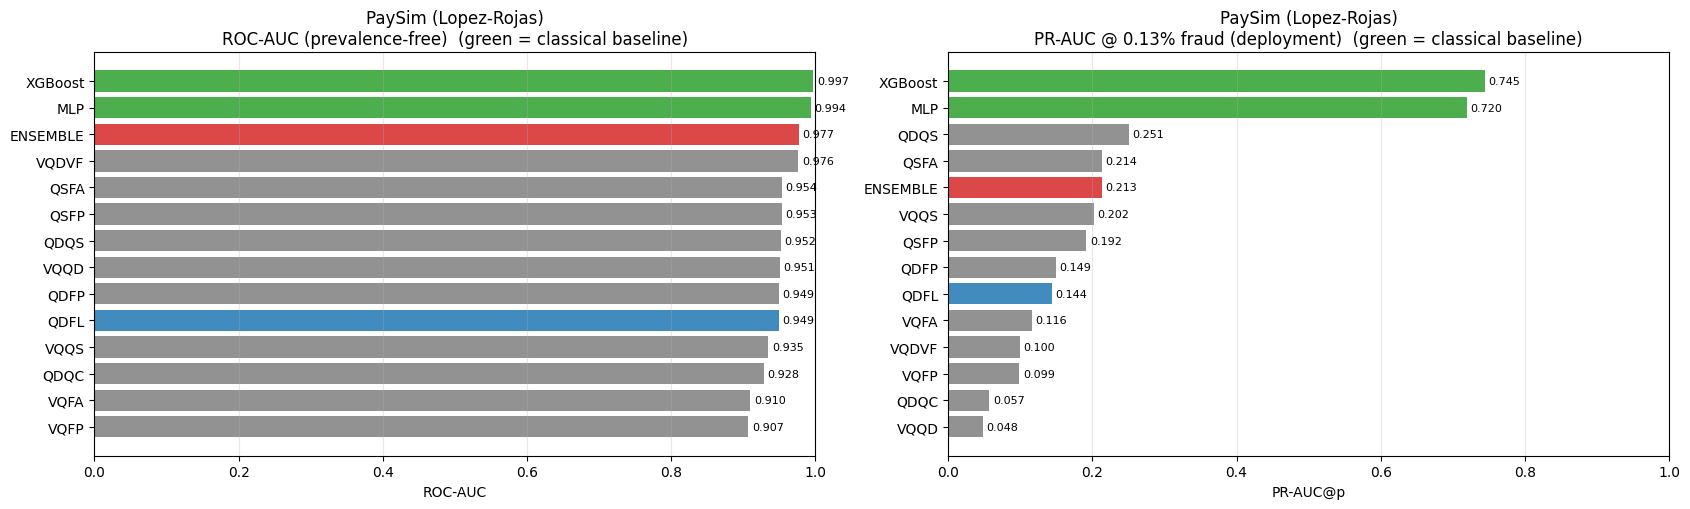

In [15]:
# ---- figure: ROC-AUC (left) and PR-AUC projected to the true rate (right) ----
fig, axes = plt.subplots(len(ALL), 2, figsize=(17, 5.2*len(ALL)))
if len(ALL)==1: axes=axes.reshape(1,2)
for r,(name,(table,table_std,ens,wt,btable)) in enumerate(ALL.items()):
    prev=PREVALENCE[name]
    er=max(ens.items(), key=lambda kv: kv[1]['ROC-AUC'])[1]
    ep=max(ens.items(), key=lambda kv: kv[1]['PR-AUC@p'])[1]
    bset=set(btable['Code'])
    for col,(metric,elab,title) in enumerate([('ROC-AUC',er['ROC-AUC'],'ROC-AUC (prevalence-free)'),
                                              ('PR-AUC@p',ep['PR-AUC@p'],f'PR-AUC @ {prev*100:.2f}% fraud (deployment)')]):
        ax=axes[r,col]
        labels=list(table['Code'])+list(btable['Code'])+['ENSEMBLE']
        vals=list(table[metric])+list(btable[metric])+[elab]
        order=np.argsort(vals); labels=[labels[i] for i in order]; vals=np.array(vals)[order]
        def _c(l):
            if l=='ENSEMBLE': return 'tab:red'
            if l in bset: return 'tab:green'
            if l=='QDFL': return 'tab:blue'
            return 'tab:gray'
        colors=[_c(l) for l in labels]
        ax.barh(labels,vals,color=colors,alpha=0.85)
        for i,v in enumerate(vals): ax.text(v+0.005,i,f'{v:.3f}',va='center',fontsize=8)
        ax.set_xlim(0,1.0); ax.set_xlabel(metric); ax.set_title(f'{name}\n{title}  (green = classical baseline)'); ax.grid(True,axis='x',alpha=0.3)
plt.tight_layout(); plt.show()

## 7b. Combine seeds across sessions -> mean +/- std

Kaggle caps a session at 12 hours, so the manuscript run is split: one dataset per session, all seeds for it. Each `(dataset, seed)` writes `results_<dataset>_seed<N>.csv` to `/kaggle/working`. To assemble the final table, add the **previous session's output** (its `results_*.csv`) as an input dataset to the current notebook; the cell below scans `/kaggle/working` and `/kaggle/input`, pools every seed it finds, and reports mean +/- std per model, baseline and ensemble. Run two sessions (Azamuke, then PaySim with session 1 attached) and this prints the complete manuscript table.

In [16]:
# ---- combine every results_*.csv (this session + any attached prior sessions) ----
import glob
SEARCH=['/kaggle/working','/kaggle/input','.']
files=sorted({f for d in SEARCH for f in glob.glob(f'{d}/**/results_*.csv', recursive=True)})
if not files:
    print('no results_*.csv found yet -- run the training cell first')
else:
    print(f'combining {len(files)} file(s):')
    for f in files: print('  ', f)
    allr=pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    allr=allr.drop_duplicates(['dataset','seed','kind','code'])
    met=['ROC-AUC','AP(bal)','PR-AUC@p','Prec@80%rec','Alert%']; order={'model':0,'baseline':1,'ensemble':2}
    for name,g in allr.groupby('dataset'):
        ns=g['seed'].nunique()
        print(f'\n===== {name}  (mean +/- std over {ns} seed(s): {sorted(g["seed"].unique())}) =====')
        ag=g.groupby(['kind','code'])[met].agg(['mean','std'])
        out=pd.DataFrame(index=ag.index)
        for k in met:
            mn=ag[(k,'mean')]; sd=ag[(k,'std')].fillna(0.0)
            out[k]=[f'{a:.4f} +/- {b:.4f}' for a,b in zip(mn,sd)]
        out=out.reset_index(); out['_o']=out['kind'].map(order)
        out=out.sort_values(['_o','code']).drop(columns='_o').set_index(['kind','code'])
        display(out)

combining 3 file(s):
   ./results_PaySim__Lopez_Rojas__seed2.csv
   /kaggle/input/notebooks/mehedihasanmugdho/qdfl-hybrid-ensemble-18-session-2/results_Primary__Azamuke_2024__seed2.csv
   /kaggle/working/results_PaySim__Lopez_Rojas__seed2.csv

===== PaySim (Lopez-Rojas)  (mean +/- std over 1 seed(s): [np.int64(2)]) =====


ROC-AUC            AP(bal)           PR-AUC@p        Prec@80%rec              Alert%
kind     code                                                                                                                   
model    QDFL                     0.9494 +/- 0.0000  0.9361 +/- 0.0000  0.1437 +/- 0.0000  0.0142 +/- 0.0000   7.2946 +/- 0.0000
         QDFP                     0.9494 +/- 0.0000  0.9385 +/- 0.0000  0.1495 +/- 0.0000  0.0127 +/- 0.0000   8.1933 +/- 0.0000
         QDQC                     0.9283 +/- 0.0000  0.9241 +/- 0.0000  0.0569 +/- 0.0000  0.0089 +/- 0.0000  11.5886 +/- 0.0000
         QDQS                     0.9524 +/- 0.0000  0.9465 +/- 0.0000  0.2506 +/- 0.0000  0.0122 +/- 0.0000   8.4926 +/- 0.0000
         QSFA                     0.9537 +/- 0.0000  0.9475 +/- 0.0000  0.2135 +/- 0.0000  0.0122 +/- 0.0000   8.4929 +/- 0.0000
         QSFP                     0.9532 +/- 0.0000  0.9473 +/- 0.0000  0.1916 +/- 0.0000  0.0120 +/- 0.0000   8.5924 +/- 0.0000
         VQDVF                    0.9764 +/- 0.0000  0.9717 +/- 0.0000  0.0997 +/- 0.0000  0.0553 +/- 0.0000   1.9029 +/- 0.0000
         VQFA                     0.9101 +/- 0.0000  0.8910 +/- 0.0000  0.1163 +/- 0.0000  0.0057 +/- 0.0000  18.2799 +/- 0.0000
         VQFP                     0.9072 +/- 0.0000  0.8855 +/- 0.0000  0.0987 +/- 0.0000  0.0057 +/- 0.0000  18.1807 +/- 0.0000
         VQQD                     0.9507 +/- 0.0000  0.9433 +/- 0.0000  0.0478 +/- 0.0000  0.0115 +/- 0.0000   8.9918 +/- 0.0000
         VQQS                     0.9350 +/- 0.0000  0.9220 +/- 0.0000  0.2020 +/- 0.0000  0.0081 +/- 0.0000  12.6871 +/- 0.0000
baseline MLP                      0.9942 +/- 0.0000  0.9950 +/- 0.0000  0.7198 +/- 0.0000  0.2159 +/- 0.0000   0.5095 +/- 0.0000
         XGBoost                  0.9974 +/- 0.0000  0.9975 +/- 0.0000  0.7446 +/- 0.0000  0.3586 +/- 0.0000   0.3114 +/- 0.0000
ensemble Meta-learner (CV stack)  0.9768 +/- 0.0000  0.9759 +/- 0.0000  0.2127 +/- 0.0000  0.0492 +/- 0.0000   2.1007 +/- 0.0000
         Top-5 weighted           0.9679 +/- 0.0000  0.9657 +/- 0.0000  0.1667 +/- 0.0000  0.0216 +/- 0.0000   4.7973 +/- 0.0000
         Weighted vote (all 11)   0.9606 +/- 0.0000  0.9560 +/- 0.0000  0.1114 +/- 0.0000  0.0162 +/- 0.0000   6.3953 +/- 0.0000


===== Primary (Azamuke 2024)  (mean +/- std over 1 seed(s): [np.int64(2)]) =====


ROC-AUC            AP(bal)           PR-AUC@p        Prec@80%rec              Alert%
kind     code                                                                                                                   
model    QDFL                     0.8751 +/- 0.0000  0.8121 +/- 0.0000  0.3380 +/- 0.0000  0.3138 +/- 0.0000  26.0425 +/- 0.0000
         QDFP                     0.8671 +/- 0.0000  0.7955 +/- 0.0000  0.3080 +/- 0.0000  0.3091 +/- 0.0000  26.6425 +/- 0.0000
         QDQC                     0.8625 +/- 0.0000  0.7881 +/- 0.0000  0.2992 +/- 0.0000  0.3157 +/- 0.0000  25.8527 +/- 0.0000
         QDQS                     0.8659 +/- 0.0000  0.8025 +/- 0.0000  0.3194 +/- 0.0000  0.3034 +/- 0.0000  26.9404 +/- 0.0000
         QSFA                     0.7693 +/- 0.0000  0.7161 +/- 0.0000  0.2293 +/- 0.0000  0.1926 +/- 0.0000  42.3753 +/- 0.0000
         QSFP                     0.7695 +/- 0.0000  0.7160 +/- 0.0000  0.2295 +/- 0.0000  0.1926 +/- 0.0000  42.3753 +/- 0.0000
         VQDVF                    0.8804 +/- 0.0000  0.8157 +/- 0.0000  0.3355 +/- 0.0000  0.3149 +/- 0.0000  26.3445 +/- 0.0000
         VQFA                     0.8617 +/- 0.0000  0.7879 +/- 0.0000  0.2977 +/- 0.0000  0.3012 +/- 0.0000  27.2404 +/- 0.0000
         VQFP                     0.8552 +/- 0.0000  0.7783 +/- 0.0000  0.2874 +/- 0.0000  0.2897 +/- 0.0000  28.3180 +/- 0.0000
         VQQD                     0.8693 +/- 0.0000  0.7964 +/- 0.0000  0.3104 +/- 0.0000  0.3136 +/- 0.0000  26.1629 +/- 0.0000
         VQQS                     0.8591 +/- 0.0000  0.7860 +/- 0.0000  0.2977 +/- 0.0000  0.2996 +/- 0.0000  27.3098 +/- 0.0000
baseline MLP                      0.8887 +/- 0.0000  0.8203 +/- 0.0000  0.3417 +/- 0.0000  0.3298 +/- 0.0000  24.7853 +/- 0.0000
         XGBoost                  0.8832 +/- 0.0000  0.8177 +/- 0.0000  0.3386 +/- 0.0000  0.3213 +/- 0.0000  25.5343 +/- 0.0000
ensemble Meta-learner (CV stack)  0.8778 +/- 0.0000  0.8157 +/- 0.0000  0.3435 +/- 0.0000  0.3193 +/- 0.0000  25.5935 +/- 0.0000
         Top-5 weighted           0.8771 +/- 0.0000  0.8065 +/- 0.0000  0.3236 +/- 0.0000  0.3125 +/- 0.0000  26.1221 +/- 0.0000
         Weighted vote (all 11)   0.8781 +/- 0.0000  0.8038 +/- 0.0000  0.3196 +/- 0.0000  0.3144 +/- 0.0000  26.1935 +/- 0.0000

## 8. How each earlier caveat is resolved

**Balanced evaluation that did not reflect deployment.** Models are still trained on balanced data (the right choice for learning a rare class), but scored on a large disjoint balanced set and then projected to each stream's true fraud rate. ROC-AUC is reported directly because it does not depend on prevalence; PR-AUC, precision-at-80%-recall and the alert rate are reported at 10.2% and 0.13%. The `AP(bal)` column is kept beside `PR-AUC@p` so the gap between the optimistic balanced number and the deployment number is explicit. The alert rate states what fraction of all traffic each model would flag at that operating point — the quantity an institution actually cares about.

**Federated quantum models brought to QDFL quality.** In the previous run the four federated quantum models (QDFL/QDFP/VQFA/VQFP) collapsed — the QDFL variant reached only ~0.80 ROC-AUC on Azamuke and ~0.58 on PaySim, far below the main-file QDFL's ~0.88 and ~0.96, despite *identical architecture*. The cause was not the model but the training regime: the main-file QDFL learns from ~12,800 samples (~2,560 per client) with a Dirichlet alpha of 0.5 and a local learning rate of 5e-4, whereas the ensemble notebook was training the same network on ~900 samples (~180 per client, some clients only a handful) with alpha 0.3 and lr 1e-3 — a data-starved, few-shot, over-heterogeneous setting in which deep local models overfit and FedAvg averages divergent updates. The fix matches the main-file regime: those four models now train on a large dedicated pool (`FED_PER_CLASS`) with alpha 0.5, lr 5e-4 and 3 local epochs. The default `FED_PER_CLASS=1500` is the fast validation setting — it removes the collapse and uses the identical main-file QDFL protocol, reaching near-parity on Azamuke; because PaySim's ~0.96 is driven by per-client data volume, exact parity there needs `FED_PER_CLASS` raised to ~5000-6000 (PaySim is fraud-limited). Quality here is a data-scale dial, not an architectural gap. The fusion and QSVM-federated models were already at quality and are unchanged. The QSVM kernel is O(N^2) so its federated variants stay capped on the moderate pool; that is a property of the kernel method, not a shortcut.

**Ensemble overfitting / not helping.** The meta-learner is `LogisticRegressionCV` with regularisation chosen by internal 5-fold CV, scored by **average precision** rather than ROC-AUC so the learned combination favours the low-false-positive tail that governs precision at the true fraud rate (on the previous run the ROC-optimised stack had high ROC-AUC but poor projected PR-AUC on PaySim). It is reported next to the weighted and top-K votes, and the comparison against the strongest single model is printed honestly; if a single model still wins, that is the finding.

**FedProx with quantum local models.** The proximal term anchors local weights to the global model. Applied to the quantum TorchLayer weights, whose gradients are weak (a single readout over many circuit parameters sits near a barren plateau), it overwhelms the learning signal and freezes the circuit at initialisation — this is why VQC+FedProx (VQFP) collapsed to chance while VQC+FedAvg (VQFA) trained normally. The proximal penalty is therefore applied to the classical head only; the quantum layers and BatchNorm are excluded (BatchNorm kept local, FedBN-style). Cross-client aggregation is unchanged (FedAvg over all parameters), so FedAvg and FedProx still differ — FedProx regularises the head's drift — without the freeze. QDFP keeps its quality because QDCN+FedAvg already trains well.

**Near-duplicate FedAvg/FedProx pairs.** Clients are a Dirichlet label-skew partition (`alpha=0.5`, matching the main file) and the FedProx coefficient is 0.05, so client drift is real and the proximal term separates QDFL vs QDFP, VQFA vs VQFP and QSFA vs QSFP, matching the premise of independent institutions.

**Misleading F1 at a fixed 0.5 cut.** Replaced entirely by prevalence-projected precision-at-recall and PR-AUC, which cannot be gamed by the class balance.

**P100 use.** The classical federated network trains on the GPU. The quantum circuits use `lightning.qubit` on CPU, the fastest backend for these qubit counts (cuStateVec needs compute capability 7.0+, above the P100's 6.0); set `QUANTUM_ON_GPU=True` to run them on the GPU through `default.qubit` instead. Everything falls back to CPU automatically when no GPU is present.

**Missing strong classical baseline.** XGBoost (or sklearn's histogram gradient booster when XGBoost is absent) and an MLP are trained on the full standardised feature set — the whole engineered representation, not the 8-dimensional compression the quantum circuits are limited to — on the same 1200-sample budget as the fusion models, and scored through the identical prevalence projection. They are printed as a separate block beneath the model table and drawn in green on the figure, so the quantum-vs-classical comparison is on equal footing: same data, same evaluation, same projected metrics. This is the honest baseline a practitioner would actually deploy, and the printed verdict states plainly which approach leads on the deployment metric. The headline ensemble is now selected by PR-AUC at the true rate rather than ROC-AUC, which is why the top-K vote — strongest in the low-false-positive tail — is reported as the ensemble on the extremely imbalanced stream, while the meta-learner remains competitive where the classes are less skewed.

**Reproducibility and rigour.** Every model is seeded before construction. `SEEDS` defaults to one for a single session; supplying several reports mean and standard deviation across seeds, which is what the final manuscript table should use.